In [32]:
# Imports
import pandas as pd
import numpy as np


In [33]:
# Load train and validation sets, parsing Time as datetime
train_df = pd.read_csv('../Data/train.csv')
val_df = pd.read_csv('../Data/val.csv')

train_df['Time'] = pd.to_datetime(train_df['Time'], format='mixed', errors='coerce')
val_df['Time'] = pd.to_datetime(val_df['Time'], format='mixed', errors='coerce')


In [34]:
# Sort by Time to guarantee chronological order before creating lag features
train_df = train_df.sort_values('Time').reset_index(drop=True)
val_df = val_df.sort_values('Time').reset_index(drop=True)


In [35]:
# Create lag and rolling features from Power[kW] on each DataFrame separately
dfs = [train_df, val_df]
for df in dfs:
    df['power_lag1'] = df['Power[kW]'].shift(1)
    df['power_lag2'] = df['Power[kW]'].shift(2)
    df['power_lag4'] = df['Power[kW]'].shift(4)
    df['power_roll4'] = df['Power[kW]'].rolling(window=4).mean()
    

# horizons in units of 15-minute steps: 1=15min, 2=30min, ..., 8=2hours
horizon_steps = {1: '15min', 2: '30min', 3: '45min', 4: '1hour',
                  5: '75min', 6: '90min', 7: '105min', 8: '2hour'}

In [36]:
# Create forecasting targets for the 15-minute and 1-hour horizons
for df in dfs:
    for steps, label in horizon_steps.items():
        df[f'target_{label}'] = df['Power[kW]'].shift(-steps)


### Null out lag/target values that cross a time gap (not exactly 15 min)

In [37]:
for df in dfs:
   
    gap_back1 = df['Time'].diff(1)
    df.loc[gap_back1 != pd.Timedelta('15min'), 'power_lag1'] = np.nan

    
    gap_back2 = df['Time'].diff(2)
    df.loc[gap_back2 != pd.Timedelta('30min'), 'power_lag2'] = np.nan

  
    gap_back4 = df['Time'].diff(4)
    df.loc[gap_back4 != pd.Timedelta('60min'), 'power_lag4'] = np.nan
    df.loc[gap_back4 != pd.Timedelta('60min'), 'power_roll4'] = np.nan


for df in dfs:
    for steps, label in horizon_steps.items():
        gap_fwd = -df['Time'].diff(-steps)
        expected_gap = pd.Timedelta(minutes=15 * steps)
        df.loc[gap_fwd != expected_gap, f'target_{label}'] = np.nan

In [38]:
# Drop rows with NaN values created by the lag/shift operations
train_rows_before = len(train_df)
val_rows_before = len(val_df)

train_df = train_df.dropna().reset_index(drop=True)
val_df = val_df.dropna().reset_index(drop=True)

train_rows_after = len(train_df)
val_rows_after = len(val_df)

print('Train rows before:', train_rows_before, 'after:', train_rows_after)
print('Val rows before:', val_rows_before, 'after:', val_rows_after)


Train rows before: 71647 after: 54187
Val rows before: 17735 after: 13439


In [39]:
# Verify alignment: target_15min at row N equals Power[kW] at row N+1, target_1hour at row N equals Power[kW] at row N+4
check_cols = ['Time', 'Power[kW]', 'power_lag1', 'target_15min', 'target_1hour']
print(train_df[check_cols].head(6))


                 Time  Power[kW]  power_lag1  target_15min  target_1hour
0 2017-01-01 08:15:00      0.132       0.020         0.176         0.332
1 2017-01-01 08:30:00      0.176       0.132         0.244         0.276
2 2017-01-01 08:45:00      0.244       0.176         0.260         0.392
3 2017-01-01 09:00:00      0.260       0.244         0.332         0.552
4 2017-01-01 09:15:00      0.332       0.260         0.276         0.644
5 2017-01-01 09:30:00      0.276       0.332         0.392         0.476


In [40]:
# Regression metrics helper
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_report(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label}  RMSE={rmse:,.3f}  MAE={mae:,.3f}  R2={r2:.3f}')
    return rmse, mae, r2


In [41]:
# Persistence baseline: predict the future value as the current Power[kW]
persistence_pred_15min = val_df['Power[kW]']
persistence_pred_1hour = val_df['Power[kW]']

rmse_15min, mae_15min, r2_15min = regression_report(val_df['target_15min'], persistence_pred_15min, label='15-min persistence baseline')
rmse_1hour, mae_1hour, r2_1hour = regression_report(val_df['target_1hour'], persistence_pred_1hour, label='1-hour persistence baseline')


15-min persistence baseline  RMSE=1.967  MAE=1.157  R2=0.830
1-hour persistence baseline  RMSE=3.250  MAE=2.272  R2=0.537


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


features_forecast = ['GHI', 'temp', 'pressure', 'humidity', 'wind_speed',
                      'rain_1h', 'snow_1h', 'clouds_all', 'dayLength',
                      'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                      'power_lag1', 'power_lag2', 'power_lag4', 'power_roll4']

X_train = train_df[features_forecast]
X_val = val_df[features_forecast]


results = []
for steps, label in horizon_steps.items():
    y_train_h = train_df[f'target_{label}']
    y_val_h = val_df[f'target_{label}']

    # persistence baseline
    pers_rmse, pers_mae, pers_r2 = regression_report(
        y_val_h, val_df['Power[kW]'], label=f'Persistence {label}')

    # linear regression
    lr_h = LinearRegression().fit(X_train, y_train_h)
    lr_rmse, lr_mae, lr_r2 = regression_report(
        y_val_h, lr_h.predict(X_val), label=f'LR {label}')

    # random forest
    rf_h = RandomForestRegressor(n_estimators=300, min_samples_leaf=10,
                                  random_state=42, n_jobs=-1).fit(X_train, y_train_h)
    rf_rmse, rf_mae, rf_r2 = regression_report(
        y_val_h, rf_h.predict(X_val), label=f'RF {label}')

    results.append({'horizon': label, 
                     'persistence_MAE': pers_mae, 'LR_MAE': lr_mae, 'RF_MAE': rf_mae,
                     'persistence_R2': pers_r2, 'LR_R2': lr_r2, 'RF_R2': rf_r2,
                     'RF_RMSE': rf_rmse})

results_df = pd.DataFrame(results)
print(results_df)

Persistence 15min  RMSE=1.967  MAE=1.157  R2=0.830
LR 15min  RMSE=1.880  MAE=1.264  R2=0.845
RF 15min  RMSE=1.737  MAE=1.044  R2=0.867
Persistence 30min  RMSE=2.524  MAE=1.615  R2=0.719
LR 30min  RMSE=2.226  MAE=1.560  R2=0.782
RF 30min  RMSE=2.044  MAE=1.280  R2=0.816
Persistence 45min  RMSE=2.899  MAE=1.961  R2=0.630
LR 45min  RMSE=2.429  MAE=1.762  R2=0.740
RF 45min  RMSE=2.236  MAE=1.429  R2=0.780
Persistence 1hour  RMSE=3.250  MAE=2.272  R2=0.537
LR 1hour  RMSE=2.602  MAE=1.934  R2=0.703
RF 1hour  RMSE=2.357  MAE=1.532  R2=0.757
Persistence 75min  RMSE=3.606  MAE=2.578  R2=0.435
LR 75min  RMSE=2.737  MAE=2.077  R2=0.675
RF 75min  RMSE=2.464  MAE=1.619  R2=0.736
Persistence 90min  RMSE=3.926  MAE=2.864  R2=0.338
LR 90min  RMSE=2.852  MAE=2.190  R2=0.650
RF 90min  RMSE=2.562  MAE=1.684  R2=0.718
Persistence 105min  RMSE=4.251  MAE=3.133  R2=0.233
LR 105min  RMSE=2.940  MAE=2.286  R2=0.633
RF 105min  RMSE=2.617  MAE=1.727  R2=0.709
Persistence 2hour  RMSE=4.554  MAE=3.386  R2=0.130
L

In [43]:
# Random Forest for the 15-min horizon, alongside the Linear Regression above
from sklearn.ensemble import RandomForestRegressor

y_train = train_df['target_15min']
y_val = val_df['target_15min']

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=10,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_train_rmse, rf_train_mae, rf_train_r2 = regression_report(y_train, rf.predict(X_train), label='RF train')
rf_val_rmse, rf_val_mae, rf_val_r2 = regression_report(y_val, rf.predict(X_val), label='RF val')


RF train  RMSE=1.347  MAE=0.787  R2=0.929
RF val  RMSE=1.737  MAE=1.044  R2=0.867


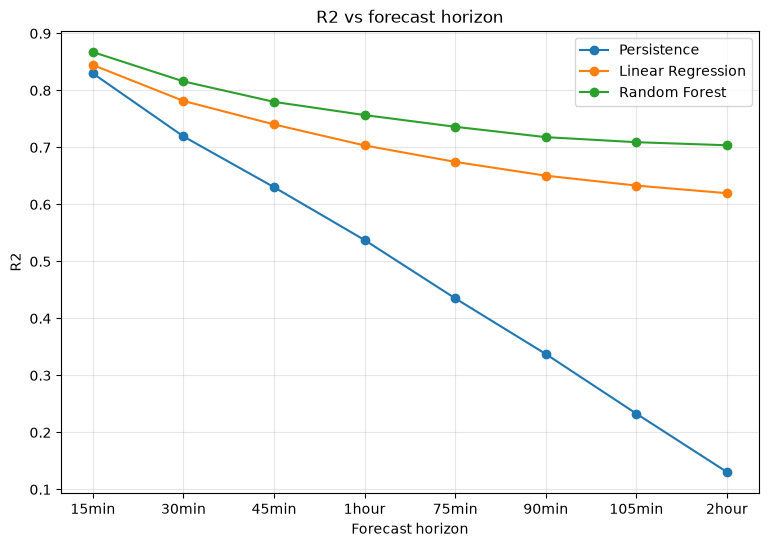

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(results_df['horizon'], results_df['persistence_R2'], marker='o', label='Persistence')
plt.plot(results_df['horizon'], results_df['LR_R2'], marker='o', label='Linear Regression')
plt.plot(results_df['horizon'], results_df['RF_R2'], marker='o', label='Random Forest')
plt.xlabel('Forecast horizon')
plt.ylabel('R2')
plt.title('R2 vs forecast horizon')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
# Final results across all three models and all eight horizons
print(results_df)


  horizon  persistence_MAE    LR_MAE    RF_MAE  persistence_R2     LR_R2  \
0   15min         1.157122  1.263732  1.044027        0.829865  0.844564   
1   30min         1.614637  1.559824  1.279856        0.719274  0.781549   
2   45min         1.961365  1.762196  1.429355        0.630171  0.740292   
3   1hour         2.271658  1.934322  1.532427        0.537424  0.703438   
4   75min         2.577755  2.077421  1.619182        0.435145  0.674608   
5   90min         2.863715  2.190192  1.684168        0.337531  0.650410   
6  105min         3.132658  2.285595  1.727114        0.232790  0.633011   
7   2hour         3.386320  2.359322  1.753547        0.130388  0.619662   

      RF_R2   RF_RMSE  
0  0.867305  1.737164  
1  0.815851  2.044003  
2  0.779893  2.236260  
3  0.756726  2.356926  
4  0.736176  2.464438  
5  0.717996  2.561653  
6  0.709154  2.617383  
7  0.703752  2.658218  
